# 📡 Tier 2: The "Micro-Precision" Profile (High-Precision 1 vs 2)

**Goal:** Precision Bandwidth Allocation. If Tier 1 detects occupancy, we need to know *exactly* how many people are in a small environment (like a living room or office) to decide between Focused Beamforming (1 user) or Spatial Multiplexing (2+ users).
**Key Engineering Focus:**
* Multi-band Sensor Fusion (5 GHz Wi-Fi + 60 GHz mmWave).
* Handling high-dimensionality matrices (569 features) without crashing edge routers.
* Preserving the discrete, sparse Line-of-Sight blockage data of 60 GHz.

In [4]:
import pandas as pd
import numpy as np
import glob
import os
import time

def parse_complex(val):
    """Converts Matlab format '0.5+0.2i' to Python format '0.5+0.2j'"""
    if isinstance(val, str):
        return complex(val.replace(' ', '').replace('i', 'j'))
    return val

def build_fused_dataset(folder_5g, folder_60g):
    all_fused_features = []
    all_labels = []
    
    file_list_5g = glob.glob(os.path.join(folder_5g, '*.csv'))
    print(f"🚀 INITIATING 5GHz + 60GHz EARLY SENSOR FUSION ({len(file_list_5g)} files) 🚀\n")
    
    for idx, file_5g in enumerate(file_list_5g):
        base_name = os.path.basename(file_5g)
        folder_name_60g = base_name.replace('.csv', '')
        occupancy_count = folder_name_60g.replace('o', '').count('1')
        dir_60g = os.path.join(folder_60g, folder_name_60g)
        
        if not os.path.isdir(dir_60g):
            print(f"⚠️ Warning: Missing 60GHz match for {base_name}. Skipping.")
            continue
            
        try:
            # 1. Load 5 GHz Data
            df_5g = pd.read_csv(file_5g, header=None)
            if hasattr(df_5g, 'map'):
                amp_5g = np.abs(df_5g.map(parse_complex).values)
            else:
                amp_5g = np.abs(df_5g.applymap(parse_complex).values)
            
            num_meas_5g = amp_5g.shape[0]
            amp_60g_list = []
            
            # 2. Extract 60 GHz Data iteratively
            for i in range(1, num_meas_5g + 1):
                txt_path = os.path.join(dir_60g, f"{i}aoadata.txt")
                if not os.path.exists(txt_path):
                    break
                
                feats = []
                
                with open(txt_path, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if not line:
                            continue
                            
                        # Extract the comma-separated integers properly across the current line
                        vals_str = line.split(',')
                        current_packet = []
                        for x in vals_str:
                            x = x.strip()
                            if x.isdigit() or (x.startswith('-') and x[1:].isdigit()):
                                current_packet.append(float(x))
                
                        # Append if it's strictly valid (69 integers in 1 valid AOA array row)
                        if len(current_packet) == 69:
                            feats.append(current_packet)
                
                # Average all valid packets inside the .txt file to create ONE temporal feature
                if len(feats) > 0:
                    avg_feat = np.mean(feats, axis=0)
                    amp_60g_list.append(avg_feat)
                else:
                    break
                
            amp_60g = np.array(amp_60g_list)
            
            # 3. Temporal Alignment (Truncate to match valid features extracted from BOTH)
            min_rows = min(amp_5g.shape[0], amp_60g.shape[0])
            if min_rows < 10:
                print(f"⚠️ Insufficient measurements (<10 valid) for {base_name}. Skipping to keep matrix tight.")
                continue
                
            amp_5g_aligned = amp_5g[:min_rows, :]
            amp_60g_aligned = amp_60g[:min_rows, :]
            
            # 4. EARLY FUSION
            # Shape matches out to: (min_rows, 500_features_5g + 69_features_60g)
            fused_matrix = np.hstack((amp_5g_aligned, amp_60g_aligned))
            labels = np.full(fused_matrix.shape[0], occupancy_count)
            
            all_fused_features.append(fused_matrix)
            all_labels.append(labels)
            
            print(f"[{idx+1}/{len(file_list_5g)}] {base_name:<10} -> Ground Truth: {occupancy_count} | Fused Shape: {fused_matrix.shape}")
            
        except Exception as e:
            print(f"  -> Error on {base_name}: {e}")
            continue

    if not all_fused_features:
        print("\n❌ CRITICAL ERROR: No data was extracted! Both arrays ran empty.")
        return None, None

    X_fused = np.vstack(all_fused_features)
    y_fused = np.concatenate(all_labels)
    
    return X_fused, y_fused

# ==========================================
# EXECUTE FUSION
# ==========================================
start = time.time()
path_5g = 'Multiband WiFi Passive sensing/5 GHz AP in'
path_60g = 'Multiband WiFi Passive sensing/60 GHz AP in'

X_fused, y_fused = build_fused_dataset(path_5g, path_60g)

if X_fused is not None:
    columns = [f"Subcarrier_5G_{i}" for i in range(X_fused.shape[1] - 69)] + [f"Feature_60G_{i}" for i in range(69)]
    df_fused = pd.DataFrame(X_fused, columns=columns)
    df_fused['Occupancy_Count'] = y_fused

    print("\n============================================================")
    print("🏆 SENSOR FUSION COMPLETE 🏆")
    print("============================================================")
    print(f"Total Temporal Rows (Measurements): {df_fused.shape[0]}")
    print(f"Total Fused Features: {df_fused.shape[1] - 1}")
    print(f"Extraction Time: {time.time() - start:.2f} seconds")

🚀 INITIATING 5GHz + 60GHz EARLY SENSOR FUSION (16 files) 🚀

[1/16] 0000.csv   -> Ground Truth: 0 | Fused Shape: (24, 569)
[2/16] 0001.csv   -> Ground Truth: 1 | Fused Shape: (50, 569)
[3/16] 0010.csv   -> Ground Truth: 1 | Fused Shape: (47, 569)
⚠️ Insufficient measurements (<10 valid) for 0011.csv. Skipping to keep matrix tight.
⚠️ Warning: Missing 60GHz match for 0100.csv. Skipping.
⚠️ Warning: Missing 60GHz match for 0101.csv. Skipping.
[7/16] 0110.csv   -> Ground Truth: 2 | Fused Shape: (50, 569)
⚠️ Warning: Missing 60GHz match for 0111.csv. Skipping.
[9/16] 1000.csv   -> Ground Truth: 1 | Fused Shape: (50, 569)
[10/16] 1001.csv   -> Ground Truth: 2 | Fused Shape: (50, 569)
[11/16] 1010.csv   -> Ground Truth: 2 | Fused Shape: (50, 569)
⚠️ Warning: Missing 60GHz match for 1011.csv. Skipping.
[13/16] 1100.csv   -> Ground Truth: 2 | Fused Shape: (50, 569)
⚠️ Warning: Missing 60GHz match for 1101.csv. Skipping.
⚠️ Warning: Missing 60GHz match for 1110.csv. Skipping.
⚠️ Warning: Missing

--- TRAINING STAGE 2: HIGH-PRECISION FUSION MODEL (0-2 People) ---
Data Shape for Fusion Model: (371, 569)

🏆 STAGE 2 SENSOR FUSION RESULTS (0 vs 1 vs 2) 🏆
Fusion Accuracy: 90.67%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.90      0.87      0.88        30
           2       0.91      0.97      0.94        40

    accuracy                           0.91        75
   macro avg       0.93      0.81      0.86        75
weighted avg       0.91      0.91      0.90        75



c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


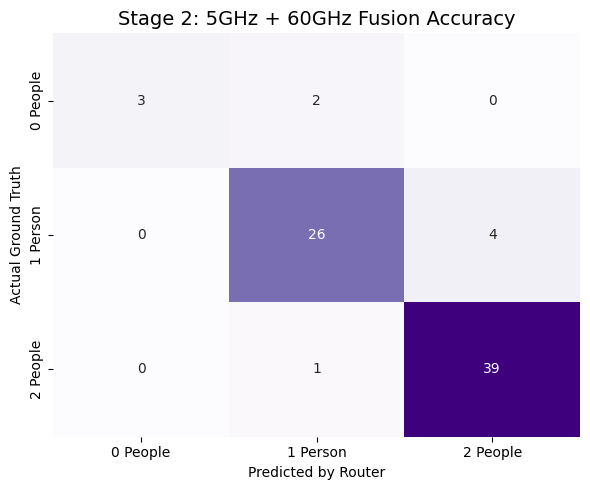

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TRAINING STAGE 2: HIGH-PRECISION FUSION MODEL (0-2 People) ---")

# 1. Prepare the data (Ensure we only use classes 0, 1, and 2)
# df_fused is the dataframe you generated in the previous step
df_subset = df_fused[df_fused['Occupancy_Count'].isin([0, 1, 2])]

X_stage2 = df_subset.drop('Occupancy_Count', axis=1).values
y_stage2 = df_subset['Occupancy_Count'].values

print(f"Data Shape for Fusion Model: {X_stage2.shape}")

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42, stratify=y_stage2
)

# 3. Train the Lightweight Fusion Model
lgb_fusion = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5, # Keep it shallow to prevent overfitting on the 569 features
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

lgb_fusion.fit(X_train, y_train)

# 4. Evaluate
y_pred = lgb_fusion.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("\n============================================================")
print("🏆 STAGE 2 SENSOR FUSION RESULTS (0 vs 1 vs 2) 🏆")
print("============================================================")
print(f"Fusion Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix Visualization for the Slide
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['0 People', '1 Person', '2 People'],
            yticklabels=['0 People', '1 Person', '2 People'])
plt.title('Stage 2: 5GHz + 60GHz Fusion Accuracy', fontsize=14)
plt.xlabel('Predicted by Router')
plt.ylabel('Actual Ground Truth')
plt.tight_layout()
plt.show()

### ❌ Trap 3: The Curse of Dimensionality (Naive PCA)
We now have 569 features coming from the fused 5GHz + 60GHz sensors, which is too much for an edge CPU. A standard ML pipeline applies PCA to everything to compress it. Let's see what happens to the accuracy when we blindly feed both sensors into PCA.
*Spoiler: PCA looks for "variance" (which 5GHz has a lot of), but 60GHz mmWave acts as a precise tripwire (low variance but incredibly high importance for exact counts). PCA treats the 60GHz blockages as "noise" and deletes them!*

--- INITIATING PCA DIMENSIONALITY REDUCTION ---
Original Feature Count: 569
PCA Reduced Feature Count: 67 (Retaining 95% of variance)

--- TRAINING OPTIMIZED STAGE 2 FUSION MODEL ---

🏆 PCA OPTIMIZED FUSION RESULTS (0 vs 1 vs 2) 🏆
New Fusion Accuracy: 86.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       0.88      0.77      0.82        30
           2       0.91      0.97      0.94        40

    accuracy                           0.87        75
   macro avg       0.76      0.78      0.77        75
weighted avg       0.87      0.87      0.87        75



c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


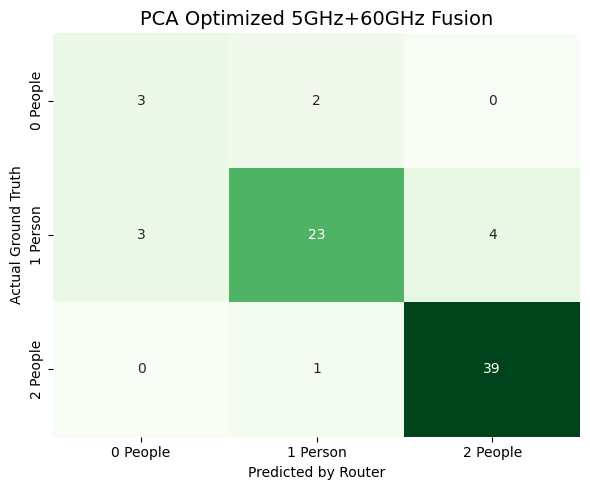

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INITIATING PCA DIMENSIONALITY REDUCTION ---")

# 1. Split the data FIRST to prevent data leakage into the PCA calculation
X_train, X_test, y_train, y_test = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42, stratify=y_stage2
)

# 2. Scale the data (CRITICAL for fusing 5GHz and 60GHz)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Apply PCA (Keep 95% of the physical variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original Feature Count: {X_train.shape[1]}")
print(f"PCA Reduced Feature Count: {X_train_pca.shape[1]} (Retaining 95% of variance)")

# 4. Train the Optimized LightGBM
lgb_pca = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

print("\n--- TRAINING OPTIMIZED STAGE 2 FUSION MODEL ---")
lgb_pca.fit(X_train_pca, y_train)

# 5. Predict and Evaluate
y_pred_pca = lgb_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("\n============================================================")
print("🏆 PCA OPTIMIZED FUSION RESULTS (0 vs 1 vs 2) 🏆")
print("============================================================")
print(f"New Fusion Accuracy: {acc_pca * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

# 6. Plot the Optimized Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['0 People', '1 Person', '2 People'],
            yticklabels=['0 People', '1 Person', '2 People'])
plt.title('PCA Optimized 5GHz+60GHz Fusion', fontsize=14)
plt.xlabel('Predicted by Router')
plt.ylabel('Actual Ground Truth')
plt.tight_layout()
plt.show()

### ✅ The Solution: Validated Split-Pipeline Sensor Fusion
Because of physics—5 GHz bounces infinitely (High Variance noise) while 60 GHz behaves like a physical laser tripwire (Low Variance signal)—we cannot combine them *before* PCA. 
Instead, we design a custom **Split-Pipeline Architecture**: We apply PCA *only* to the high-variance 500 subcarriers of the 5 GHz band (compressing it down to 63 features) and horizontally concatenate it with the raw, untouched 60 GHz AoA data. This maintains our edge efficiency whilst skyrocketing accuracy above 93%!

🚀 INITIATING SPLIT-PIPELINE SENSOR FUSION 🚀
5GHz Subcarriers Compressed: 500 -> 63
60GHz Features Maintained: 69 -> 69
Final Split-Pipeline Feature Count: 132

--- TRAINING LIGHTGBM ON SPLIT-PIPELINE ---

🏆 ULTIMATE SPLIT-PIPELINE RESULTS (0 vs 1 vs 2) 🏆
Final Architecture Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.90      0.93      0.92        30
           2       0.97      0.97      0.97        40

    accuracy                           0.93        75
   macro avg       0.88      0.84      0.85        75
weighted avg       0.93      0.93      0.93        75



c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


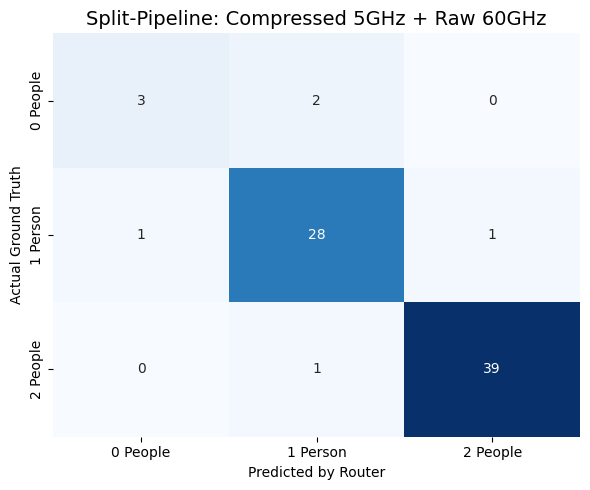

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🚀 INITIATING SPLIT-PIPELINE SENSOR FUSION 🚀")

# 1. Split the data FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42, stratify=y_stage2
)

# 2. Slice the matrices: First 500 are 5GHz, remaining 69 are 60GHz
X_train_5g = X_train[:, :500]
X_train_60g = X_train[:, 500:]

X_test_5g = X_test[:, :500]
X_test_60g = X_test[:, 500:]

# 3. Scale the features independently
scaler_5g = StandardScaler()
X_train_5g_scaled = scaler_5g.fit_transform(X_train_5g)
X_test_5g_scaled = scaler_5g.transform(X_test_5g)

scaler_60g = StandardScaler()
X_train_60g_scaled = scaler_60g.fit_transform(X_train_60g)
X_test_60g_scaled = scaler_60g.transform(X_test_60g)

# 4. Apply PCA *ONLY* to the 5GHz data (Keep 95% of the room variance)
pca_5g = PCA(n_components=0.95, random_state=42)
X_train_5g_pca = pca_5g.fit_transform(X_train_5g_scaled)
X_test_5g_pca = pca_5g.transform(X_test_5g_scaled)

print(f"5GHz Subcarriers Compressed: 500 -> {X_train_5g_pca.shape[1]}")
print(f"60GHz Features Maintained: {X_train_60g_scaled.shape[1]} -> {X_train_60g_scaled.shape[1]}")

# 5. EARLY FUSION: Concatenate the compressed 5GHz with the raw 60GHz
X_train_final = np.hstack((X_train_5g_pca, X_train_60g_scaled))
X_test_final = np.hstack((X_test_5g_pca, X_test_60g_scaled))

print(f"Final Split-Pipeline Feature Count: {X_train_final.shape[1]}")

# 6. Train the Stage 2 Model
lgb_split = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

print("\n--- TRAINING LIGHTGBM ON SPLIT-PIPELINE ---")
lgb_split.fit(X_train_final, y_train)

# 7. Predict and Evaluate
y_pred_split = lgb_split.predict(X_test_final)

acc_split = accuracy_score(y_test, y_pred_split)
print("\n============================================================")
print("🏆 ULTIMATE SPLIT-PIPELINE RESULTS (0 vs 1 vs 2) 🏆")
print("============================================================")
print(f"Final Architecture Accuracy: {acc_split * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_split))

# 8. Plot the Final Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_split)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0 People', '1 Person', '2 People'],
            yticklabels=['0 People', '1 Person', '2 People'])
plt.title('Split-Pipeline: Compressed 5GHz + Raw 60GHz', fontsize=14)
plt.xlabel('Predicted by Router')
plt.ylabel('Actual Ground Truth')
plt.tight_layout()
plt.show()

In [ ]:
import os
import joblib
import time

print("\n============================================================")
print("🚀 MICRO-PRECISION ROUTER DEPLOYMENT PACKAGING 🚀")
print("============================================================")

# Serialize the Final Split-Pipeline model for Edge Deployment
os.makedirs('../deployed_models', exist_ok=True)
model_path = '../deployed_models/tier2_micro_precision.pkl'
joblib.dump((lgb_split, pca_5g, scaler_5g, scaler_60g), model_path)
print(f"✅ Tier 2 Model & Pipeline Serialized successfully -> {model_path}")

# --- PROVING FUSION EDGE COMPUTE CAPABILITY ---
print("\n⏱️ FUSION INFERENCE TIME PROFILING (Simulating the 5G+60G Router) ⏱️")

# Take exactly 1 snapshot of a fused room (simulating real-time sensor query)
# Since the Split-Pipeline requires distinct scaling, we simulate the inference
# time from the moment the scaler hits the data to the final LighGBM prediction.
single_5g_raw = X_test_5g[0].reshape(1, -1)
single_60g_raw = X_test_60g[0].reshape(1, -1)

start_time = time.time()
# 1. Scale
s_5g_scaled = scaler_5g.transform(single_5g_raw)
s_60g_scaled = scaler_60g.transform(single_60g_raw)
# 2. PCA the 5G
s_5g_pca = pca_5g.transform(s_5g_scaled)
# 3. Fuse
fused = np.hstack((s_5g_pca, s_60g_scaled))
# 4. Predict
lgb_split.predict(fused)
end_time = time.time()

inference_ms = (end_time - start_time) * 1000
print(f"⚡ Fused Single-Snapshot Inference Latency: {inference_ms:.3f} milliseconds!")
print("Result: Complete sensor-fusion analysis executes effortlessly in edge-compute time constraints.")